# I refered to https://www.kaggle.com/georgearnall/yale-face-recognition
# I learned a lot of things from this notebook. Thank you very much.

In [4]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
pip install mtcnn

Note: you may need to restart the kernel to use updated packages.


In [1]:
from matplotlib import pyplot as plt
import cv2
from PIL import Image

import mtcnn
from mtcnn.mtcnn import MTCNN
from matplotlib.patches import Rectangle

from os import listdir
from tqdm import tqdm
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
DIRECTORY = "'F:/archive/yalefaces/"
DIRECTORY_train='F:/archive/yalefaces/train/'
DIRECTORY_test='F:/archive/yalefaces/test/'

# 1.Data Analysis

# 1) Data Sample

(243, 320, 3)


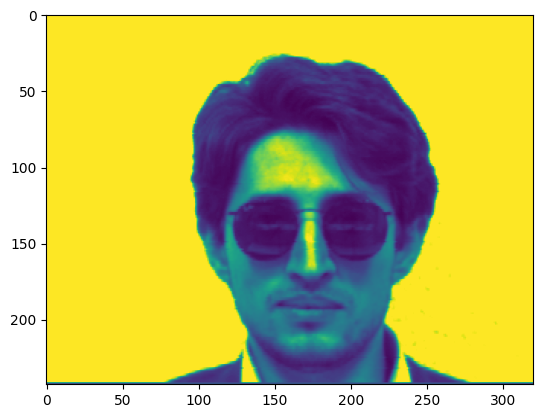

In [5]:
filename = "F:/archive/yalefaces/test/subject03.glasses.gif"
pixels = plt.imread(filename)

rgb_pixels = np.stack((pixels, pixels, pixels), axis=2)
print(rgb_pixels.shape)
plt.imshow(pixels)
plt.show()

# 2) MTCNN

In [6]:
detector = MTCNN()

results = detector.detect_faces(rgb_pixels)
results

[{'box': [118, 86, 106, 138],
  'confidence': np.float64(0.9917528033256531),
  'keypoints': {'nose': [np.int64(173), np.int64(168)],
   'mouth_right': [np.int64(194), np.int64(193)],
   'right_eye': [np.int64(198), np.int64(138)],
   'left_eye': [np.int64(147), np.int64(138)],
   'mouth_left': [np.int64(151), np.int64(192)]}}]

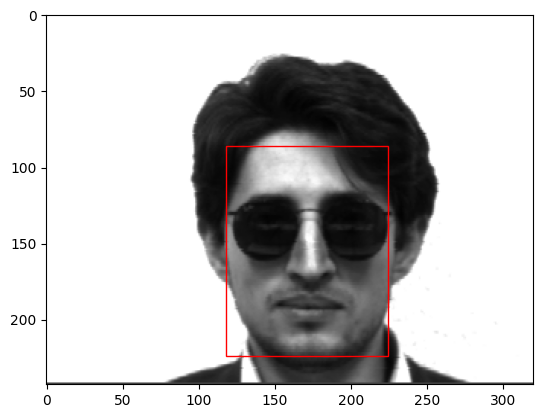

In [7]:
def draw_image_with_boxes(data, result_list):
    plt.imshow(data)
    ax = plt.gca()
    for result in result_list:
        x, y, width, height = result['box']
        rect = Rectangle((x, y), width, height, fill=False, color='red')
        ax.add_patch(rect)
    plt.show()

draw_image_with_boxes(rgb_pixels, results)

# 3) Extract and normalise the face pixels

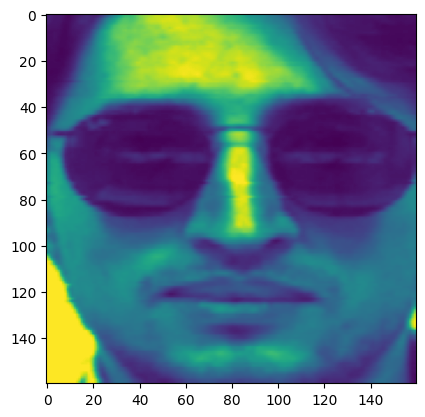

In [8]:
def extract_face_from_file(filename, required_size=(160, 160)):
    image = Image.open(filename)
    
    return extract_face(image, required_size)

def extract_face(image, required_size=(160, 160)):
    image = image.convert('RGB')
    pixels = np.asarray(image)
    results = detector.detect_faces(pixels)

    x1, y1, width, height = results[0]['box']
    
    x1, y1 = abs(x1), abs(y1)
    x2, y2 = x1 + width, y1 + height

    face = pixels[y1:y2, x1:x2]

    image = Image.fromarray(face)
    image = image.resize(required_size)
    face_array = np.asarray(image)
    gray_face = cv2.cvtColor(face_array, cv2.COLOR_BGR2GRAY)
    
    return gray_face

detector = MTCNN()

face_pixels = extract_face_from_file("F:/archive/yalefaces/test/subject03.glasses.gif")

plt.imshow(face_pixels)

# 2.Data set　〜　135 train datas and 30 test datas

In [9]:
def list_files(directory, contains):
    return list(f for f in listdir(directory) if contains in f)

100%|██████████| 16/16 [00:02<00:00,  5.34it/s]


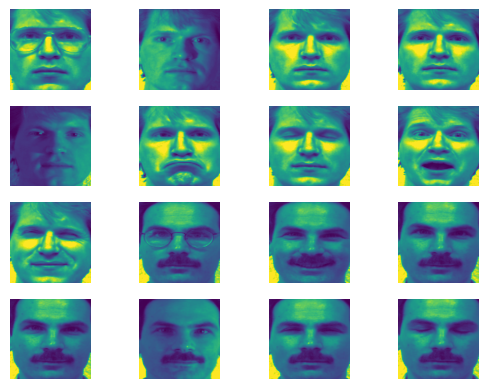

In [10]:
i = 1
faces = list()
for filename in tqdm(list_files(DIRECTORY_train, "subject")[0:16]):
    # path
    path = DIRECTORY_train + filename
    # get face
    face = extract_face_from_file(path)
    # plot
    plt.subplot(4, 4, i)
    plt.axis('off')
    plt.imshow(face)
    faces.append(face)
    i += 1
plt.show()

In [11]:
filenames = pd.DataFrame(list_files(DIRECTORY_train, "subject"))

df_train = filenames[0].str.split(".", expand=True)
df_train["filename"] = filenames

df_train = df_train.rename(columns = {0:"subject", 1:"category"})
df_train['subject'] = df_train.subject.str.replace('subject' , '')
df_train.apply(pd.to_numeric, errors='coerce').dropna()
df_train['subject'] = pd.to_numeric(df_train["subject"])
df_train

,subject,category,2,filename
0,1,glasses,gif,subject01.glasses.gif
1,1,leftlight,gif,subject01.leftlight.gif
2,1,noglasses,gif,subject01.noglasses.gif
3,1,normal,gif,subject01.normal.gif
4,1,rightlight,gif,subject01.rightlight.gif
...,...,...,...,...
130,15,noglasses,gif,subject15.noglasses.gif
131,15,normal,gif,subject15.normal.gif
132,15,sleepy,gif,subject15.sleepy.gif
133,15,surprised,gif,subject15.surprised.gif


In [12]:
filenames2 = pd.DataFrame(list_files(DIRECTORY_test, "subject"))

df_test = filenames2[0].str.split(".", expand=True)
df_test["filename"] = filenames2

df_test = df_test.rename(columns = {0:"subject", 1:"category"})
df_test['subject'] = df_test.subject.str.replace('subject' , '')
df_test.apply(pd.to_numeric, errors='coerce').dropna()
df_test['subject'] = pd.to_numeric(df_test["subject"])
df_test

,subject,category,2,filename
0,1,gif,None,subject01.gif
1,1,happy,gif,subject01.happy.gif
2,2,centerlight,gif,subject02.centerlight.gif
3,2,leftlight,gif,subject02.leftlight.gif
4,3,glasses,gif,subject03.glasses.gif
5,3,leftlight,gif,subject03.leftlight.gif
6,4,leftlight,gif,subject04.leftlight.gif
7,4,surprised,gif,subject04.surprised.gif
8,5,sleepy,gif,subject05.sleepy.gif
9,5,surprised,gif,subject05.surprised.gif


In [13]:
x_train=df_train.loc[:,['category','filename']]
x_test=df_test.loc[:,['category','filename']]
y_train=df_train.loc[:,['subject']]
y_test=df_test.loc[:,['subject']]

In [14]:
y_train=y_train.to_numpy()
y_test=y_test.to_numpy()

In [15]:
y_train = y_train.tolist()
y_test = y_test.tolist()

In [16]:
detector = MTCNN()

def load_dataset1(dataset):
    faces = list()
    for filename in tqdm(dataset["filename"]):
        path = DIRECTORY_train + filename
        # get face
        face = extract_face_from_file(path)
        faces.append(face)
    return np.asarray(faces)

In [17]:
detector = MTCNN()

def load_dataset2(dataset):
    faces = list()
    for filename in tqdm(dataset["filename"]):
        path = DIRECTORY_test + filename
        # get face
        face = extract_face_from_file(path)
        faces.append(face)
    return np.asarray(faces)

In [18]:
x_test = load_dataset2(x_test)
x_train = load_dataset1(x_train)

print(x_test.shape)
print(x_train.shape)

100%|██████████| 135/135 [00:19<00:00,  6.99it/s]

(30, 160, 160)
(135, 160, 160)


# 3. Convolutional Neural Network Model

In [19]:
TRAINING_DATA_DIRECTORY = "data/train"
TESTING_DATA_DIRECTORY = "data/test"
NUM_CLASSES = 15
EPOCHS = 25
BATCH_SIZE = 20
NUMBER_OF_TRAINING_IMAGES = 135
NUMBER_OF_TESTING_IMAGES = 30
IMAGE_HEIGHT = 160
IMAGE_WIDTH = 160

In [20]:
import os 

def save_keras_dataset(setname, dataset, labels, per_class):
    data = sorted(list(zip(labels, dataset)), key=lambda x: x[0])

    j = 0
    for label, gray_img in tqdm(data):
        j = (j% per_class) + 1
        
        directory = f"data/{setname}/class_{label}/"
        if not os.path.exists(directory):
                os.makedirs(directory)
        cv2.imwrite(f"{directory}class_{label}_{j}.png",gray_img)

In [21]:
import shutil
shutil.rmtree(r'data', ignore_errors=True)

# Save datasets
save_keras_dataset("test", x_test, y_test, 3)
save_keras_dataset("train", x_train, y_train, 8)

100%|██████████| 135/135 [00:00<00:00, 240.06it/s]


In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
def data_generator():
    return ImageDataGenerator(
        rescale=1./255,
        
    )

def add_noise(img):
    """Add random noise to an image"""
    VARIABILITY = 35
    deviation = VARIABILITY*random.random()
    noise = np.random.normal(0, deviation, img.shape)
    img += noise
    np.clip(img, 0., 255.)
    return img

In [23]:
training_generator = data_generator().flow_from_directory(
    TRAINING_DATA_DIRECTORY,
    target_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale'
)

testing_generator = data_generator().flow_from_directory(
    TESTING_DATA_DIRECTORY,
    target_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    class_mode='categorical',
    color_mode='grayscale'
)

validation_generator = data_generator().flow_from_directory(
    TESTING_DATA_DIRECTORY,
    target_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

Found 120 images belonging to 15 classes.


Found 30 images belonging to 15 classes.
Found 30 images belonging to 15 classes.


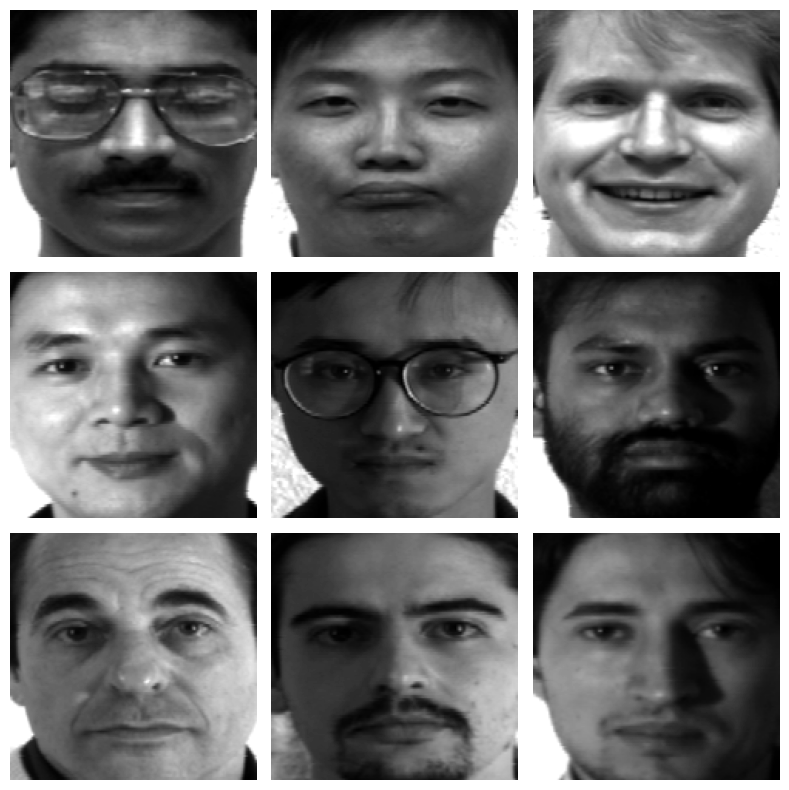

In [24]:
sample_images, _ = next(testing_generator)

f, xyarr = plt.subplots(3, 3, figsize=(8, 8))
xyarr[0, 0].imshow(sample_images[0].squeeze(), cmap='gray')
xyarr[0, 1].imshow(sample_images[1].squeeze(), cmap='gray')
xyarr[0, 2].imshow(sample_images[2].squeeze(), cmap='gray')
xyarr[1, 0].imshow(sample_images[3].squeeze(), cmap='gray')
xyarr[1, 1].imshow(sample_images[4].squeeze(), cmap='gray')
xyarr[1, 2].imshow(sample_images[5].squeeze(), cmap='gray')
xyarr[2, 0].imshow(sample_images[6].squeeze(), cmap='gray')
xyarr[2, 1].imshow(sample_images[7].squeeze(), cmap='gray')
xyarr[2, 2].imshow(sample_images[8].squeeze(), cmap='gray')

for i in range(3):
    for j in range(3):
        xyarr[i, j].axis('off')

plt.tight_layout()
plt.show()


In [25]:
import keras
class MCDropout(keras.layers.Dropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

In [26]:
from tensorflow.keras import models
from tensorflow.keras.layers import Activation, ZeroPadding2D, MaxPooling2D, Conv2D, Flatten, Dense, Dropout
from tensorflow.keras import regularizers, constraints

model = models.Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='linear', input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 1), padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2=0.01)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(l2=0.01)))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(512, activation='relu', kernel_initializer="glorot_uniform", kernel_regularizer=regularizers.l2(l2=0.01)))

model.add(MCDropout(rate=0.5))

model.add(Dense(NUM_CLASSES, activation='softmax', kernel_initializer="glorot_uniform"))

c:\Users\neodev-pc-windows\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 78, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 39, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout (MCDropout)          │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,334,543 (81.38 MB)

 Trainable params: 21,334,543 (81.38 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes=True, show_layer_names=True)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [29]:
from tensorflow.keras import optimizers, losses
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping()

model.compile(
    loss=losses.CategoricalCrossentropy(from_logits=True),
    optimizer=optimizers.Adam(learning_rate=0.0003),
    metrics=["accuracy"]
)

history = model.fit(
    training_generator,
    steps_per_epoch=(NUMBER_OF_TRAINING_IMAGES//BATCH_SIZE ),
    epochs=EPOCHS,
    validation_data=testing_generator,
    shuffle=True,
    validation_steps=(NUMBER_OF_TESTING_IMAGES//BATCH_SIZE),
#     callbacks=[early_stopping]
)

c:\Users\neodev-pc-windows\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25


c:\Users\neodev-pc-windows\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\backend\tensorflow\nn.py:666: UserWarning: "`categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.0820 - loss: 13.4343 - val_accuracy: 0.1667 - val_loss: 11.1506
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 962ms/step - accuracy: 0.1717 - loss: 10.4818 - val_accuracy: 0.0667 - val_loss: 8.8087
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2946 - loss: 8.2982 - val_accuracy: 0.3333 - val_loss: 6.9904
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.3229 - loss: 6.5703 - val_accuracy: 0.2667 - val_loss: 5.7854
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 960ms/step - accuracy: 0.4163 - loss: 5.3192 - val_accuracy: 0.2333 - val_loss: 4.8545
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 581ms/step - accuracy: 0.4242 - loss: 4.4138 - val_accuracy: 0.4333 - val_loss: 4.2010
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 567ms/step - accuracy: 0.6156 - loss: 3.6263 - val_accuracy: 0.6333 - val_loss: 3.6382
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 584ms/step - accuracy: 0.7952 - loss: 3.0642 - val_accuracy: 0.5000 - val_loss: 3.7200
Epoch 9/

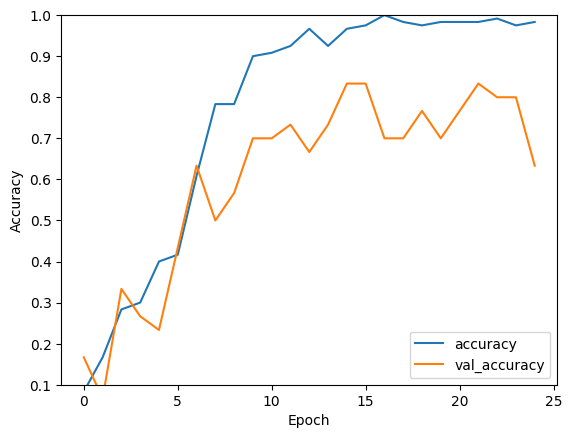

In [30]:
plot_folder = "plot"
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.1, 1])
plt.legend(loc='lower right')

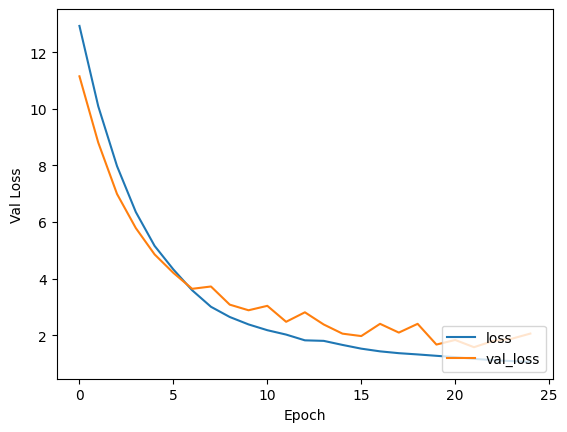

In [31]:
plot_folder = "plot"
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.legend(loc='lower right')

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)
print(classification_report(validation_generator.classes, y_pred))
print(validation_generator.classes)
print(y_pred)
print('Confusion Matrix')
print(confusion_matrix(validation_generator.classes, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       0.50      0.50      0.50         2
           3       1.00      1.00      1.00         2
           4       0.67      1.00      0.80         2
           5       1.00      0.50      0.67         2
           6       0.67      1.00      0.80         2
           7       0.67      1.00      0.80         2
           8       0.00      0.00      0.00         2
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00         2
          11       0.20      0.50      0.29         2
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       0.00      0.00      0.00         2

    accuracy                           0.73        30
   macro avg       0.71      0.73      0.

c:\Users\neodev-pc-windows\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\neodev-pc-windows\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\neodev-pc-windows\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control th

In [33]:
model.save("model.h5")
